# Aliartos Water-Gradient Validation & Calibration — Miscanthus × giganteus

Uses the full Aliartos irrigation gradient (0 / 25 / 50 / 100% PET) to (1) validate the simulated
yield-versus-water response and (2) calibrate phenology and water-stress parameters by non-linear
optimisation, following the two-stage NLOPT approach (GN_DIRECT_L then LN_SBPLX) of notebook 11.

## Irrigation as TimedEvents, not StateEvents
The treatments are defined as a fraction of seasonal PET (a fixed seasonal water supply), not a
soil-moisture-threshold rule, so TimedEvents express them directly. TimedEvents also keep the water
input fixed while CFET and DEPNR are varied, so the optimiser sees only the model's response change;
StateEvents would re-trigger as those parameters move, co-varying the input with the response and
breaking identifiability. Finally, StateEvents require a trailing empty campaign to define the end
date, which reintroduces the one-day-past-weather error. With TimedEvents the run ends at the last
harvest.

## Assumptions
- Observed target: DMY (oven-dry total biomass) as the field equivalent of WOFOST TAGP.
- Observed point per year x level = mean over the replicate plots (3 blocks x 2 densities = 6).
- All four treatments run the same water-limited model (Wofost72_WLP_CWB); they differ only in the
  irrigation supplied, so 100% PET approaches the potential yield.
- Irrigation is reconstructed: for fraction f, seasonal irrigation = f x min(growing-season ET0, cap),
  spread over evenly spaced applications. This is an assumption to sensitivity-test, not a measured
  schedule; confirm the cap and scheduling against the Aliartos protocol.
- Year alignment: Aliartos labels a year by its January harvest, so observed year = growing year + 1.
- Free parameters: TSUM1 (phenology), CFET and DEPNR (water stress). The gradient is what makes CFET
  and DEPNR identifiable.

In [1]:
import sys, os
from pathlib import Path
import datetime as dt
import numpy as np
import pandas as pd
import nlopt
import pcse
import matplotlib.pyplot as plt
from pcse.input import (YAMLCropDataProvider, CABOFileReader,
                        WOFOST72SiteDataProvider, ExcelWeatherDataProvider,
                        YAMLAgroManagementReader)
from pcse.base import ParameterProvider
from pcse.models import Wofost72_WLP_CWB

print(f"python : {sys.version.split()[0]}")
print(f"PCSE   : {pcse.__version__}")

# Okabe-Ito
PP_COLOR, WLP_COLOR, OBS_COLOR = "#0072B2", "#D55E00", "#000000" 

python : 3.13.12
PCSE   : 6.0.12


In [2]:
project   = Path("/Users/paulianoprescu/Projects/wofost_miscanthus/giganteus")
input_dir = project / "calibration"
crop_file    = input_dir / "crop_params" / "miscanthus_giganteus.yaml"
soil_file    = input_dir / "soil" / "input_params_eu" / "soil" / "soil_aliartos_gr.soil"
weather_file = input_dir / "weather" / "aliartos_weather.xlsx"
agro_dir     = input_dir / "agromanager"
obs_file     = input_dir / "aliartos_observations.csv" 

In [3]:
# Crop (YAMLCropDataProvider needs a crops.yaml index in the folder)
(crop_file.parent / "crops.yaml").write_text("available_crops:\n- miscanthus_giganteus\n")
cropdata = YAMLCropDataProvider(fpath=crop_file.parent, force_reload=True)
cropdata.set_active_crop("miscanthus_giganteus", "miscanthus_giganteus")

soildata = CABOFileReader(soil_file)
# SITE PARAMETERS
# Compute WAV as 50% between field capacity and wilting point
SMFCF = soildata["SMFCF"]
SMW   = soildata["SMW"]
RDI   = cropdata["RDI"]        # initial rooting depth (cm)
wav_init = 0.5 * (SMFCF - SMW) * RDI * 25   # mm
print(f"Initial WAV = {wav_init:.1f} mm  (50% between FC and WP)")

sitedata = WOFOST72SiteDataProvider(WAV=wav_init)

print(sitedata)
parameters = ParameterProvider(cropdata=cropdata, soildata=soildata, sitedata=sitedata)

wdp = ExcelWeatherDataProvider(weather_file)
print("inputs loaded")

Initial WAV = 20.6 mm  (50% between FC and WP)
{'IFUNRN': 0, 'NOTINF': 0, 'SSI': 0.0, 'SSMAX': 0.0, 'WAV': 20.625, 'SMLIM': 0.4}
inputs loaded


In [4]:
obs = pd.read_csv(obs_file, sep=";")
PET_FRAC = {0: 0.0, 1: 0.25, 2: 0.5, 3: 1.0}     # irrigation code -> fraction of PET

GROWING_YEARS = list(range(2013, 2026))          # simulated growing seasons
CALIB_YEARS   = list(range(2015, 2022))          # OBSERVED years scored in calibration (mid-life)

# observed mean DMY per (observed year, treatment)
obs_mean = (obs.groupby(["cal_year", "irrigation"])["DMY"].mean()
              .rename("DMY_obs").reset_index())
print(obs_mean.head())

   cal_year  irrigation    DMY_obs
0      2013           0  13.383000
1      2013           1  18.982833
2      2013           2  21.348000
3      2013           3  23.288667
4      2014           0  10.825667


## Agromanagement generator with irrigation (TimedEvents)
One multi-year agromanagement file per treatment. The 100% treatment receives `min(seasonal ET0, cap)`
of irrigation; lower treatments are that scaled by their fraction, so the four levels stay distinct.
No trailing empty campaign, so the run ends at the last harvest.

In [5]:
def seasonal_et0_mm(wdp, year, start=(4, 1), end=(10, 31)):
    """Growing-season reference ET (mm). PCSE ET0 is cm/day."""
    d, last, tot = dt.date(year, *start), dt.date(year, *end), 0.0
    while d <= last:
        tot += wdp(d).ET0 * 10.0
        d += dt.timedelta(days=1)
    return tot

def irrigation_rows(wdp, year, frac, n_apps=10, start=(5, 1), end=(9, 30),
                    cap_mm=400.0, eff=0.9):
    """Reconstructed irrigation events for one season (amounts in cm).
    Full (100%) treatment = min(seasonal ET0, cap); others scale by frac so levels stay distinct."""
    if frac == 0:
        return []
    total_cm = (frac * min(seasonal_et0_mm(wdp, year), cap_mm)) / 10.0
    per_cm = round(total_cm / n_apps, 3)
    d0, d1 = dt.date(year, *start), dt.date(year, *end)
    step_days = (d1 - d0).days / (n_apps - 1)
    rows = []
    for i in range(n_apps):
        d = d0 + dt.timedelta(days=round(i * step_days))
        rows.append(f"        - {d.isoformat()}: {{amount: {per_cm}, efficiency: {eff}}}")
    return rows

def build_irrigation_agro(frac, years, wdp, out_path):
    """Write a multi-year agromanagement YAML with irrigation TimedEvents for one treatment.
    No trailing empty campaign: the run ends at the last harvest."""
    crop = "miscanthus_giganteus"
    blocks = []
    for k, yr in enumerate(years):
        camp_start = f"{yr-1}-10-01" if k == 0 else f"{yr}-01-01"   # spin-up only for first year
        irr = irrigation_rows(wdp, yr, frac)
        if irr:
            timed = ("    TimedEvents:\n"
                     "    -   event_signal: irrigate\n"
                     "        name: Timed irrigation events\n"
                     "        comment: all irrigation amounts in cm\n"
                     "        events_table:\n" + "\n".join(irr))
        else:
            timed = "    TimedEvents: null"
        blocks.append(
            f"- {camp_start}:\n"
            f"    CropCalendar:\n"
            f"        crop_name: {crop}\n"
            f"        variety_name: {crop}\n"
            f"        crop_start_date: {yr}-01-01\n"
            f"        crop_start_type: emergence\n"
            f"        crop_end_date: {yr}-12-30\n"
            f"        crop_end_type: harvest\n"
            f"        max_duration: null\n"
            f"{timed}\n"
            f"    StateEvents: null")
    yaml_text = "Version: 1.0.0\nAgroManagement:\n" + "\n".join(blocks) + "\n"
    out_path.write_text(yaml_text)
    return out_path

# Build one agromanagement per treatment and read them back
agros = {}
for code_, frac in PET_FRAC.items():
    p = build_irrigation_agro(frac, GROWING_YEARS, wdp, agro_dir / f"miscgig_agro_irr{code_}.yaml")
    agros[code_] = YAMLAgroManagementReader(p)
print("agromanagement written for treatments:", list(agros))

agromanagement written for treatments: [0, 1, 2, 3]


In [6]:
class ModelRerunner:
    """Reruns the water-limited model for every irrigation treatment with the given parameter
    values, returning end-of-season TAGP (t/ha) per growing year per treatment.
    Mirrors the ModelRerunner pattern of notebook 11."""
    parameters = ["TSUM1", "CFET", "DEPNR"]

    def __init__(self, params, wdp, agros):
        self.params = params
        self.wdp = wdp
        self.agros = agros            # {treatment_code: agromanagement}

    def __call__(self, par_values):
        if len(par_values) != len(self.parameters):
            raise RuntimeError(f"Expected {len(self.parameters)} values, got {len(par_values)}")
        self.params.clear_override()
        for name, value in zip(self.parameters, par_values):
            self.params.set_override(name, value)

        records = []
        for code_, agro in self.agros.items():
            wof = Wofost72_WLP_CWB(self.params, self.wdp, agro)
            wof.run_till_terminate()
            out = pd.DataFrame(wof.get_output()).set_index("day")
            out.index = pd.to_datetime(out.index)
            tagp = out["TAGP"].groupby(out.index.year).max() / 1000.0   # t/ha per growing year
            for gyr, val in tagp.items():
                records.append({"growing_year": int(gyr), "irrigation": code_, "DMY_sim": val})
        return pd.DataFrame(records)

In [7]:
class ObjectiveFunctionCalculator:
    """Normalised, weighted RMSE between simulated end-of-season TAGP and observed DMY, summed
    over irrigation treatments. Mirrors notebook 11, with treatments in place of the per-variable
    mapping. Measured endpoints are weighted above the reconstructed intermediate levels."""
    treatment_weights = {0: 1.0, 1: 0.5, 2: 0.5, 3: 1.0}

    def __init__(self, params, wdp, agros, obs_mean, calib_years):
        self.modelrerunner = ModelRerunner(params, wdp, agros)
        self.obs_mean = obs_mean
        self.calib_years = set(calib_years)
        self.n_calls = 0

    def __call__(self, par_values, grad=None):
        self.n_calls += 1
        print(".", end="")
        sim = self.modelrerunner(par_values)
        sim["cal_year"] = sim["growing_year"] + 1            # harvest-year alignment
        merged = sim.merge(self.obs_mean, on=["cal_year", "irrigation"], how="inner")
        merged = merged[merged["cal_year"].isin(self.calib_years)]

        weighted_RMSE = 0.0
        for code_, w in self.treatment_weights.items():
            sub = merged[merged["irrigation"] == code_]
            if len(sub) == 0:
                continue
            mean_obs = sub["DMY_obs"].mean()
            diff = (sub["DMY_sim"] - sub["DMY_obs"]) / mean_obs
            weighted_RMSE += w * np.sqrt(np.mean(diff ** 2))
        return weighted_RMSE

In [8]:
ofc = ObjectiveFunctionCalculator(parameters, wdp, agros, obs_mean, CALIB_YEARS)
default_values = [2336.0, 1.2, 5.0]      # TSUM1, CFET, DEPNR
print("\ndefault objective:", round(ofc(default_values), 4))

.
default objective: 1.0463


## Two-stage non-linear optimisation (notebook 11 structure)
Each objective evaluation runs four multi-year simulations, so the optimiser can take several
minutes. If it is too slow, narrow `CALIB_YEARS`, lower `max_eval`, or parallelise the four
treatment runs with joblib.

In [9]:
def run_optimizer(optimizer, start_values, tolerance, max_eval=400):
    lower_boundary = [1500.0, 0.8, 3.0]
    upper_boundary = [3800.0, 1.4, 8.0]
    init_step_size = [ 100.0, 0.05, 0.5]

    nlopt.srand(19730703)
    opt = nlopt.opt(optimizer, len(start_values))
    objfunc_calculator = ObjectiveFunctionCalculator(parameters, wdp, agros, obs_mean, CALIB_YEARS)
    opt.set_min_objective(objfunc_calculator)
    opt.set_lower_bounds(lower_boundary)
    opt.set_upper_bounds(upper_boundary)
    opt.set_initial_step(init_step_size)
    opt.set_maxeval(max_eval)
    opt.set_ftol_rel(tolerance)
    x = opt.optimize(start_values)

    print("\nminimum value =", opt.last_optimum_value())
    print("result code   =", opt.last_optimize_result())
    print("function calls =", objfunc_calculator.n_calls)
    for name, value in zip(ModelRerunner.parameters, x):
        print(f"{name}: {value:.3f}")
    return x

default_values = [2336.0, 1.2, 5.0]
print("FIRST STAGE (GN_DIRECT_L):")
x0 = run_optimizer(nlopt.GN_DIRECT_L, default_values, tolerance=0.1)
print("\nSECOND STAGE (LN_SBPLX):")
x1 = run_optimizer(nlopt.LN_SBPLX, x0, tolerance=0.01)

FIRST STAGE (GN_DIRECT_L):
...........
minimum value = 1.043377425143769
result code   = 3
function calls = 11
TSUM1: 2650.000
CFET: 1.300
DEPNR: 7.167

SECOND STAGE (LN_SBPLX):
...........................
minimum value = 1.0415163745607272
result code   = 3
function calls = 27
TSUM1: 1763.281
CFET: 1.400
DEPNR: 8.000


## Validation: simulated vs observed dose-response

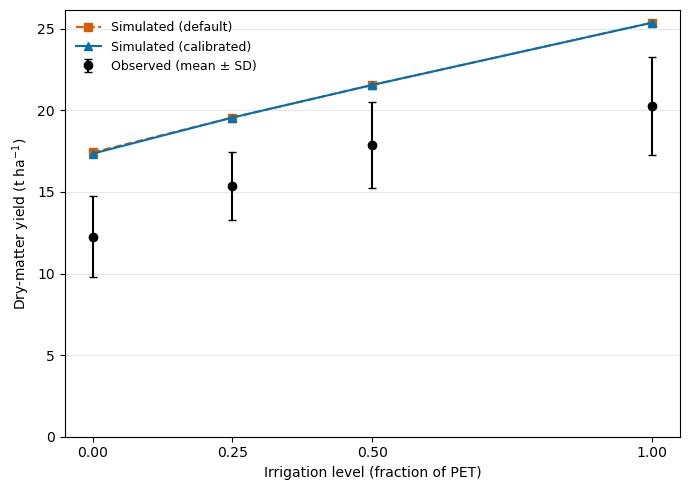

In [10]:
def dose_response(par_values):
    sim = ModelRerunner(parameters, wdp, agros)(par_values)
    sim["cal_year"] = sim["growing_year"] + 1
    sim = sim[sim["cal_year"].isin(CALIB_YEARS)]
    return sim.groupby("irrigation")["DMY_sim"].mean()

obs_dr = (obs[obs["cal_year"].isin(CALIB_YEARS)]
            .groupby("irrigation")["DMY"].agg(["mean", "std"]))
sim_def = dose_response(default_values)
sim_cal = dose_response(list(x1))

fracs = [PET_FRAC[c] for c in obs_dr.index]
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(fracs, obs_dr["mean"], yerr=obs_dr["std"], fmt="o", color=OBS_COLOR,
            capsize=3, ms=6, label="Observed (mean ± SD)")
ax.plot(fracs, [sim_def[c] for c in obs_dr.index], "s--", color=WLP_COLOR, label="Simulated (default)")
ax.plot(fracs, [sim_cal[c] for c in obs_dr.index], "^-",  color=PP_COLOR,  label="Simulated (calibrated)")
ax.set_xlabel("Irrigation level (fraction of PET)")
ax.set_ylabel("Dry-matter yield (t ha$^{-1}$)")
ax.set_xticks(list(PET_FRAC.values()))
ax.set_ylim(bottom=0)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig("aliartos_gradient_calibration.pdf", bbox_inches="tight")
plt.show()